# 1. AI비전과 반도체 이미지



## 1.1 제조 현장에서 이미지는 어떤 역할을 할까?

* 제조 현장에서는 제품의 상태를 확인하기 위해 다양한 종류의 이미지가 사용됨
* 다음과 같은 작업에 이미지를 활용할 수 있음

    - 제품 표면의 흠집이나 오염 확인
    - 부품의 위치와 조립 상태 확인
    - 패턴의 이상 여부 검사
    - 정상 제품과 불량 제품 분류
    - 불량이 발생한 위치 탐지

* AI비전은 **정상과 이상을 구분하거나, 특정 패턴을 인식하도록 모델을 학습**하는 방식으로 활용









## 1.2 반도체 분야에서 사용하는 이미지

* 반도체 제조에서도 여러 형태의 이미지 데이터가 사용됨

    - 웨이퍼 표면 이미지
    - 반도체 패턴 이미지
    - 패키지 또는 부품 검사 이미지
    - 웨이퍼맵(Wafer Map)

## 1.3 AI비전의 목적에 따른 문제 분류

- 이미지 전체가 어떤 종류인지 판단하기 → **분류(Classification)**
- 이미지 안에서 특정 물체나 결함의 위치 찾기 → **객체 검출(Object Detection)**
- 픽셀 단위로 영역 구분하기 → **분할(Segmentation)**
- 정상 이미지와 다른 이상 패턴 찾기 → **이상탐지(Anomaly Detection)**

---

---
# 2. 웨이퍼맵이란?

## 2.1 웨이퍼맵의 기본 개념

* **웨이퍼 위 die의 검사 결과를 위치 정보와 함께 표현한 데이터**

* 검사 결과를 웨이퍼의 실제 위치와 대응하여 표시하면 어느 위치의 die가 정상이고 불량인지 한눈에 확인할 수 있다.


## 2.2 웨이퍼맵을 이미지처럼 볼 수 있는 이유

* 웨이퍼맵은 2차원 배열 형태로 표현할 수 있음

* 각 위치의 값은 해당 위치가 어떤 상태인지를 나타냄

* 이번 데이터에서는 다음과 같은 값을 사용한다.

    - `0` : 웨이퍼 영역 바깥
    - `1` : 정상 die
    - `2` : 불량 die

    예를 들어 하나의 웨이퍼맵이 다음과 같이 저장되어 있다고 생각할 수 있다.

    ```text
    0 0 1 1 0
    0 1 1 2 1
    1 1 2 2 1
    0 1 1 1 0
    0 0 1 0 0
    ```

* 이 데이터는 숫자로 저장되어 있지만, 색을 지정하여 화면에 출력하면 하나의 이미지처럼 볼 수 있다.

* 따라서 웨이퍼맵의 불량 분포를 **공간적인 패턴**으로 해석할 수 있다.

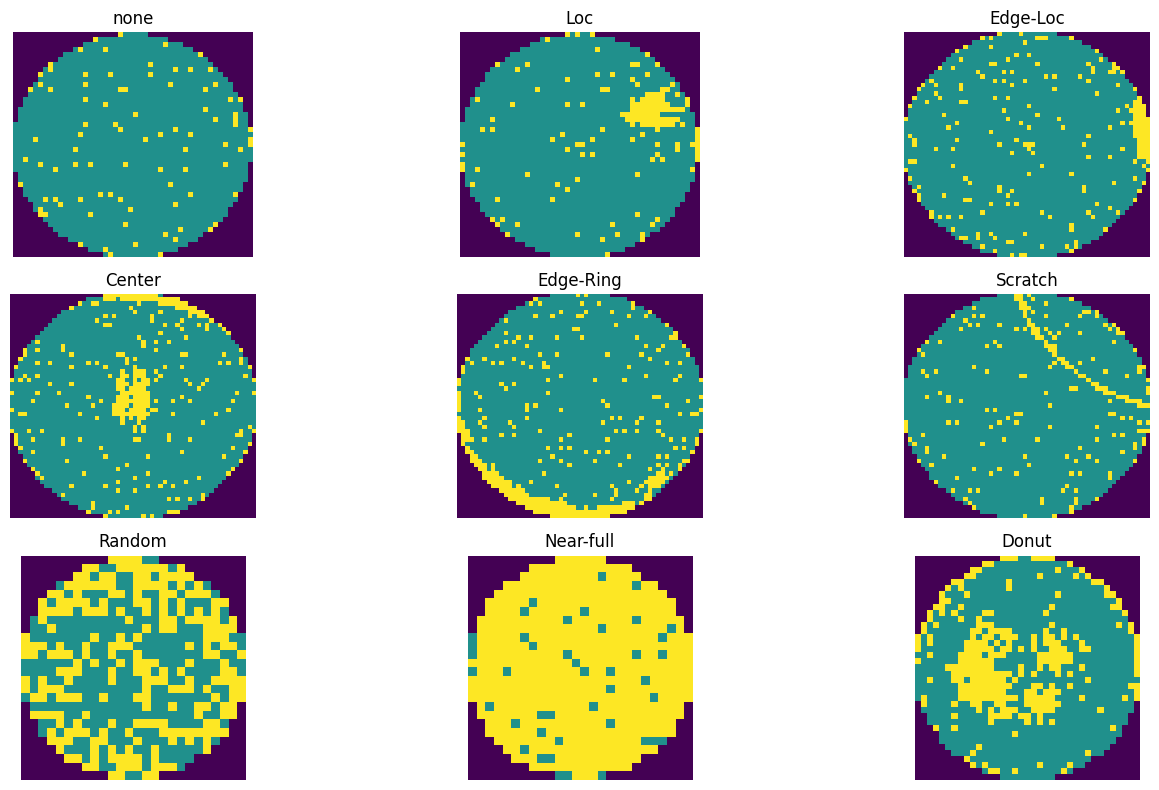

## 2.3 불량은 패턴을 만들 수 있다

* 웨이퍼의 불량 die가 항상 무작위로 나타나는 것은 아니다.

* 공정이나 장비 문제의 특성에 따라 특정 위치에 불량이 집중되면서 웨이퍼맵에 특징적인 형태가 나타날 수 있다.

    - 중앙 부근에 집중되는 패턴
    - 웨이퍼 가장자리에 집중되는 패턴
    - 선 형태로 길게 나타나는 패턴
    - 특정 영역에 국소적으로 모이는 패턴

* 이러한 공간적 특징을 이용하면 불량 패턴을 분류할 수 있다.

## 2.4 오늘 사용할 세 가지 패턴

- `Center`
    - 불량 die가 웨이퍼의 중앙 부근에 집중되는 패턴

- `Edge-Loc`
    - 불량 die가 웨이퍼 가장자리의 특정 영역에 집중되는 패턴

- `Scratch`
    - 불량 die가 선 또는 길쭉한 형태로 나타나는 패턴입니다.




## 2.5 관찰



- 같은 클래스의 웨이퍼는 정말 서로 비슷한가?
- 클래스마다 어떤 공간적인 특징이 있는가?
- 사람이 보기에 구분이 쉬운 경우와 어려운 경우가 있는가?
- CNN은 이러한 차이를 어떻게 학습할 수 있을까?



---
# 3. CNN 모델을 이용하여 웨이퍼맵의 불량 패턴 분류하기

## 3.1 데이터 불러오기

* 이번 실습에서는 미리 준비된 웨이퍼맵 데이터를 사용


In [ ]:
# 구글 드라이브 마운트
from google.colab import drive

drive.mount('/content/drive')

In [ ]:
import pandas as pd

# 파일 경로는 본인 환경에 맞게 수정
# TODO:

df = pd.read_pickle(file_path)

# .pkl 파일
# pickle은 Python 객체를 그대로 저장할 수 있는 파일 형식
# 이번 파일에는 DataFrame이 저장되어 있음

## 3.2 데이터 탐색


In [ ]:
# 데이터 구성 확인
# TODO:

# waferMap : 웨이퍼맵 데이터
# label : 웨이퍼의 불량 패턴 종류

In [ ]:
# 데이터 구조 확인
# TODO:

df.head()
# 한 행 = 웨이퍼 하나
# waferMap : 2차원 배열 저장됨
# label : 클래스 이름 저장됨

In [ ]:
# 클래스별 데이터 개수 확인
# TODO:

In [ ]:
# 웨이퍼맵 하나 확인
sample = df['waferMap'].iloc[0]

print(type(sample))
print(sample.shape)
print(sample)

# 웨이퍼맵 하나는 NumPy 2차원 배열
# 모든 데이터 크기는 26 × 26

In [ ]:
# waferMap에 저장된 값 확인
import numpy as np

# TODO:

# 0: 웨이퍼 바깥
# 1: 정상 die
# 2: 불량 die

In [ ]:
# 웨이퍼맵 시각화
import matplotlib.pyplot as plt

# TODO:


In [ ]:
# 라벨과 함께 출력
# TODO:
# sample =

plt.imshow(sample['waferMap'])
plt.title(sample['label'])
plt.axis('off')
plt.show()

In [ ]:
# 클래스별 웨이퍼맵 비교
# TODO:
# classes =

fig, axes = plt.subplots(3, 5, figsize=(10, 6))

for row, cls in enumerate(classes):

    samples = df[df['label'] == cls].head(5)

    for col, (_, sample) in enumerate(samples.iterrows()):

        axes[row, col].imshow(sample['waferMap'])
        axes[row, col].axis('off')

        if col == 0:
            axes[row, col].set_title(cls)

plt.tight_layout()
plt.show()

# Center: 중앙 부근에 불량 집중
# Edge-Loc: 가장자리 특정 영역에 불량 집중
# Scratch: 선형 또는 길쭉한 패턴
# 같은 클래스라도 모양이 완전히 동일하지 않음

---
# 4. CNN 학습용 데이터 만들기

## 4.1 입력 데이터 `X` 만들기




In [ ]:
import numpy as np

# waferMap 컬럼의 2차원 배열을 하나의 NumPy 배열로 묶음.
# TODO:

print(X.shape)

In [ ]:
# 현재 shape: (180, 26, 26)
# CNN 입력을 위해 채널 차원 추가 필요

# TODO:

print(X.shape)

# - 변경 후 shape: `(180, 26, 26, 1)`
# - 마지막 `1`은 채널 수

## 4.2 정답 데이터 `y` 만들기

In [ ]:
from sklearn.preprocessing import LabelEncoder

# 문자열 라벨을 숫자로 변환함.
# TODO:


# TODO: print()


# 문자열 클래스 → 숫자 라벨로 변환
# 클래스 번호는 le.classes_ 순서에 따라 결정됨

## 4.3 클래스별 데이터 수 확인

In [ ]:
# 각 클래스가 몇 개씩 구성되는지 확인
# TODO:


# 각 클래스 60개씩 구성됨

## 4.4 학습용 / 검증용 데이터 분리

In [ ]:
from sklearn.model_selection import train_test_split

# 학습 데이터: 80%
# 검증 데이터: 20%
# stratify=y로 클래스 비율 유지

# TODO:

print(X_train.shape)
print(X_val.shape)
print(y_train.shape)
print(y_val.shape)


## 4.5 픽셀값 정규화

In [ ]:
# 웨이퍼맵 값은 0, 1, 2로 구성됨.

# TODO:


# 정규화 후 값 확인:
print(X_train.min())
print(X_train.max())
# 기존 범위: 0 ~ 2
# 정규화 후 범위: 0 ~ 1

## 4.6 최종 입력 형태 확인

In [ ]:
print('X_train:', X_train.shape)
print('X_val:', X_val.shape)
print('y_train:', y_train.shape)
print('y_val:', y_val.shape)

---

# 5. CNN 모델 구현 및 학습

## 5.1 CNN 모델 만들기

In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

# TODO:
# model =



# - 입력 크기: `26 × 26 × 1`
# - 출력 클래스: 3개
# - Conv2D + MaxPooling2D를 2번 사용함

## 5.2 모델 구조 확인

In [ ]:
model.summary()
# - 각 층의 출력 shape 확인
# - 학습할 파라미터 수 확인

## 5.3 모델 컴파일

In [ ]:

# TODO:


# - optimizer: `adam`
# - 다중 클래스 분류 문제
# - 정답이 숫자 라벨이므로 `sparse_categorical_crossentropy` 사용

## 5.4 모델 학습

In [ ]:

# TODO:
# history =


# - `epochs=20`: 전체 학습 데이터를 20번 반복
# - `batch_size=16`: 한 번에 16개씩 학습
# - 학습 데이터와 검증 데이터 성능 함께 확인

## 5.5 학습 결과 확인

In [ ]:
# 마지막 epoch에서 train/valid accuracy 출력

# TODO:


# - train accuracy와 validation accuracy 차이 확인
# - 차이가 너무 크면 과적합 가능성 있음

## 5.6 Accuracy 변화 시각화

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# - 학습이 진행되면서 정확도가 어떻게 변하는지 확인
# - train과 validation의 차이 관찰

## 5.7 Loss 변화 시각화

In [ ]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# - loss가 감소하는지 확인
# - validation loss가 다시 증가하면 과적합 가능성 있음

## 5.8 검증 데이터 성능 평가

In [ ]:
# TODO: evaluate()


print('Validation accuracy:', val_acc)

# - 전체 검증 데이터 기준 성능 확인
# - 다음 단계에서 클래스별 예측 결과도 확인함

---

# 6. 모델 성능 확인

## 6.1 예측 결과 만들기

In [ ]:
y_pred = model.predict(X_val)

# TODO: np.argmax()


# - softmax 출력에서 가장 큰 값을 가진 클래스 선택
# - 예측 결과를 클래스 번호로 변환함

## 6.2 실제값과 예측값 비교

In [ ]:
print('실제값:', y_val[:10])
print('예측값:', y_pred[:10])

# - 예측이 맞은 경우와 틀린 경우 확인

## 6.3 Confusion Matrix 확인

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_pred)

print(cm)

# - 행: 실제 클래스
# - 열: 예측 클래스
# - 어떤 클래스끼리 많이 헷갈리는지 확인 가능

## 6.4 Classification Report 확인

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_val,
        y_pred,
        target_names=le.classes_
    )
)

# - precision
# - recall
# - f1-score
# - 클래스별 성능 비교 가능

## 6.5 클래스 번호 확인

In [ ]:
print(le.classes_)

# - confusion matrix의 클래스 순서 확인
# - 숫자 라벨과 실제 클래스 이름 연결

## 6.6 오분류 데이터 확인

In [ ]:
wrong_idx = np.where(y_val != y_pred)[0]

print('오분류 개수:', len(wrong_idx))
print(wrong_idx[:10])

# - 예측이 틀린 데이터의 인덱스 확인

## 6.7 오분류 이미지 시각화

In [ ]:
plt.figure(figsize=(10, 6))

for i, idx in enumerate(wrong_idx[:9]):

    plt.subplot(3, 3, i + 1)

    plt.imshow(X_val[idx].squeeze())

    true_label = le.inverse_transform([y_val[idx]])[0]
    pred_label = le.inverse_transform([y_pred[idx]])[0]

    plt.title(
        f'True: {true_label}\nPred: {pred_label}'
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

# - 실제 라벨과 예측 라벨 비교
# - 모델이 어떤 형태의 웨이퍼맵에서 헷갈리는지 직접 확인

## 6.8 결과 해석

- 전체 accuracy만으로는 모델 성능을 충분히 설명하기 어려움
- 클래스별 성능과 오분류 이미지도 함께 확인할 필요 있음
- 다음 단계에서 실습용 데이터와 원본 데이터의 차이를 확인함

---

# 7. 원본 웨이퍼맵 데이터 확인

지금까지 사용한 데이터는 학습하기 쉽도록 미리 정리한 데이터임.

```text
실습용 데이터
- 26 × 26 크기
- 3개 클래스
- 클래스별 60개
- 라벨이 있는 데이터만 사용
```

실제 원본 데이터는 훨씬 복잡하게 구성되어 있음.

## 7.1 원본 데이터 불러오기

In [ ]:
import pandas as pd

# TODO: 본인 경로로 설정
# file_path =


# TODO: pickle 파일 읽어오기
# df_raw =


# - 원본 전체 데이터가 크기 때문에 분할한 파일 중 하나만 사용함

## 7.2 원본 데이터 구조 확인

In [ ]:
# TODO: shape, columns, head()



# 원본에는 웨이퍼맵 외에도 여러 메타데이터가 포함되어 있음.

# - `waferMap`
# - `dieSize`
# - `lotName`
# - `waferIndex`
# - `trainTestLabel`
# - `failureType`

## 7.3 라벨 데이터 정리

In [ ]:
# `failureType`이 리스트가 중첩된 형태로 저장되어 있으므로 문자열만 추출함.

def extract_label(x):
    try:
        return x[0][0]
    except:
        return None

df_raw['failureType_clean'] = df_raw['failureType'].apply(extract_label)

df_raw['failureType_clean'].value_counts(dropna=False)


# - 라벨이 없는 데이터도 많이 포함되어 있음
# - `none`은 특정 불량 패턴이 없음을 의미하는 실제 클래스
# - `None`은 라벨이 없는 데이터

## 7.4 웨이퍼맵 크기 확인

In [ ]:
# TODO: apply(), value_counts()



# 전체 shape 종류 확인
# TODO: nunique()



# - 원본 전체에서는 웨이퍼맵 크기가 하나로 통일되어 있지 않음
# - 확인 결과 전체 데이터에 162종류의 shape 존재함

## 7.5 클래스별 데이터 분포 확인

In [ ]:
# TODO: 'failureType_clean'의 분포 확인



# - 클래스별 데이터 수가 크게 다름
# - 일부 클래스는 매우 많고 일부 클래스는 매우 적음

## 7.6 처음 사용한 데이터는 어떻게 만든 것일까?

첫 실습용 데이터에는 다음 처리가 적용되어 있었음.

```text
원본 WM-811K
      ↓
라벨이 있는 데이터 선택
      ↓
26 × 26 웨이퍼맵 선택
      ↓
Center / Edge-Loc / Scratch 선택
      ↓
클래스별 60개 추출
      ↓
실습용 데이터셋
```

## 생각해보기

- 왜 크기가 같은 웨이퍼맵만 선택했을까?
- 왜 모든 클래스를 사용하지 않았을까?
- 왜 클래스별 데이터 개수를 같게 만들었을까?
- 이런 처리를 하지 않고 바로 CNN에 넣으면 어떤 문제가 생길까?

---

# 8. 원본 데이터에서 학습용 데이터 만들기



이번에는 원본 데이터에서 직접 학습에 사용할 데이터를 선택하고 정리해봄.

- 사용할 데이터 선택
- shape 확인
- 클래스 선택
- 클래스별 데이터 수 조정
- CNN 학습용 데이터 구성

## 8.1 사용할 데이터 조건 정하기

이번 실습에서는 다음 조건으로 데이터를 선택함.

```text
웨이퍼맵 크기: 26 × 26

사용 클래스:
- Center
- Edge-Loc
- Scratch
```

## 8.2 분할된 원본 파일 순회하기

원본 데이터가 크기 때문에 여러 개의 파일로 나누어 저장함.

각 파일에서 조건에 맞는 데이터만 추출함.

In [ ]:
import pandas as pd
import os
import gc

folder = '/content/drive/MyDrive/_for_exercise/WM811K_split/'

target_classes = ['Center', 'Edge-Loc', 'Scratch']
target_shape = (26, 26)

collected = []

for i in range(1, 21):
    path = os.path.join(folder, f'LSWMD_{i:02d}.pkl')
    part = pd.read_pickle(path)

    # failureType 문자열 추출
    part['failureType_clean'] = part['failureType'].apply(
        lambda x: x[0][0] if len(x) > 0 else None
    )

    # 26x26 + 목표 클래스만 선택
    selected = part[
        (part['waferMap'].apply(lambda x: x.shape == target_shape)) &
        (part['failureType_clean'].isin(target_classes))
    ].copy()

    collected.append(selected)

    print(f'{i:02d}번 파일: {len(selected)}개 확보')

    del part
    gc.collect()

## 8.3 추출한 데이터 합치기

In [ ]:
candidates = pd.concat(collected, ignore_index=True)

print(candidates.shape)
print(candidates['failureType_clean'].value_counts())

# - 20개 파일에서 조건에 맞는 데이터만 모음
# - 클래스별 전체 개수 확인 가능

## 8.4 클래스별 같은 개수 추출

In [ ]:
# 각 클래스에서 60개씩 랜덤 추출함.

# TODO:
# subset =

subset['failureType_clean'].value_counts()

# - 클래스별 60개
# - 전체 180개

## 8.5 데이터 순서 섞기

In [ ]:
subset = (
    subset
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

## 8.6 필요한 컬럼만 남기기

In [ ]:
# subset에서 필요한 컬럼만 골라오기
# TODO: copy()
# subset_clean =


# 컬럼명 변경
# TODO: rename()


subset_clean.head()


## 8.7 처음 사용한 데이터와 비교

In [ ]:
print(subset_clean.shape)
print(subset_clean['label'].value_counts())

# 처음 실습에서 사용한 데이터와 같은 구조가 만들어짐.

```text id="6h9u0c"
분할된 원본 데이터 전체
        ↓
각 파일에서 26 × 26 선택
        ↓
3개 클래스 선택
        ↓
조건에 맞는 데이터 모두 수집
        ↓
클래스별 60개 추출
        ↓
필요한 컬럼만 선택
        ↓
CNN 실습용 데이터
```


## 8.8 학습용 데이터 구성에서 결정한 것

- 어떤 크기의 웨이퍼맵을 사용할 것인가
- 어떤 클래스를 사용할 것인가
- 클래스별 데이터 수를 어떻게 맞출 것인가
- 모델 학습에 필요한 정보만 어떻게 추출할 것인가

> 데이터 전처리는 정해진 작업을 무조건 적용하는 것이 아니라  
> 데이터와 학습 목적에 따라 필요한 처리를 결정하는 과정임

---
# 9. 직접 만든 데이터로 CNN 학습하기

In [ ]:
## 9.1 입력 데이터 `X` 만들기

import numpy as np

X = np.stack(subset_clean['waferMap'].values)
X = X[..., np.newaxis]

print(X.shape)


In [ ]:
## 9.2 정답 데이터 `y` 만들기

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(subset_clean['label'])

print(le.classes_)
print(np.bincount(y))


In [ ]:
## 9.3 학습용 / 검증용 데이터 분리

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
## 9.4 픽셀값 정규화

X_train = X_train / 2.0
X_val = X_val / 2.0

# - 기존 값: `0, 1, 2`
# - 정규화 후 범위: `0 ~ 1`

In [ ]:
## 9.5 CNN 모델 만들기

# 처음 실습과 동일한 구조 사용함.

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Input(shape=(26, 26, 1)),

    Conv2D(16, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])


In [ ]:
## 9.6 모델 컴파일

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
## 9.7 모델 학습

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_val, y_val),
    verbose=1
)


In [ ]:
## 9.8 검증 성능 확인

val_loss, val_acc = model.evaluate(X_val, y_val)

print('Validation accuracy:', val_acc)


In [ ]:
## 9.9 Confusion Matrix 확인

from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_val)
y_pred = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_val, y_pred)

print(cm)


## 처음 결과와 비교

- 처음에는 사전에 처리가 된 데이터 사용함
- 이번에는 원본 데이터에서 직접 조건을 정해 subset을 만듦
- 같은 조건으로 데이터를 구성하면 비슷한 학습 결과를 기대할 수 있음

```text id="7b5n2q"
원본 데이터
    ↓
데이터 선택 및 정리
    ↓
학습용 데이터
    ↓
CNN 학습
    ↓
성능 평가
```

- 모델 학습 이전에 데이터 구성 과정이 필요함
- 어떤 데이터를 선택하는지에 따라 학습 결과도 달라질 수 있음


---

# 10. 정리



이번 실습의 전체 흐름

```text
웨이퍼맵 이해
    ↓
정제된 데이터로 CNN 분류
    ↓
원본 데이터 확인
    ↓
학습에 사용할 데이터 선택
    ↓
subset 구성
    ↓
CNN 재학습
    ↓
성능 확인
```

## 오늘 확인한 내용

- 웨이퍼맵은 불량 die의 공간적 분포를 나타내는 데이터임
- 같은 클래스라도 웨이퍼맵 형태가 완전히 동일하지 않음
- 원본 데이터는 바로 CNN에 넣기 어려움
- 학습 전에 데이터 선택과 정리가 필요함
- 이미지 크기, 클래스 구성, 데이터 수를 직접 결정해야 함
- 모델 성능은 모델 구조뿐 아니라 데이터 구성에도 영향을 받음
